# EDA - Eccomerce Analyst

### Overview of Dataset

Objective: วิเคราะห์ภาพกว้างก่อน เพื่อ เข้าใจในชุดข้อมูล และ เข้าใจบริบท และ เพื่อคาดการณ์ในการนําข้อมูล ที่เหลือไปใช้อย่างเหมาะสม

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/clean/clean_data.csv")

วิเคราะห์กลุ่มลูกค้า ชาย หญิง จํานวนข้อมูลใน Dataset 

In [3]:
# Gender distribution
male = df[df["Gender"] == "Male"]
female = df[df["Gender"] == "Female"]

print("Amount of Male: ", len(male))
print("Amount of Female: ", len(female))

Amount of Male:  524
Amount of Female:  476


In [4]:
df.shape

(1000, 12)

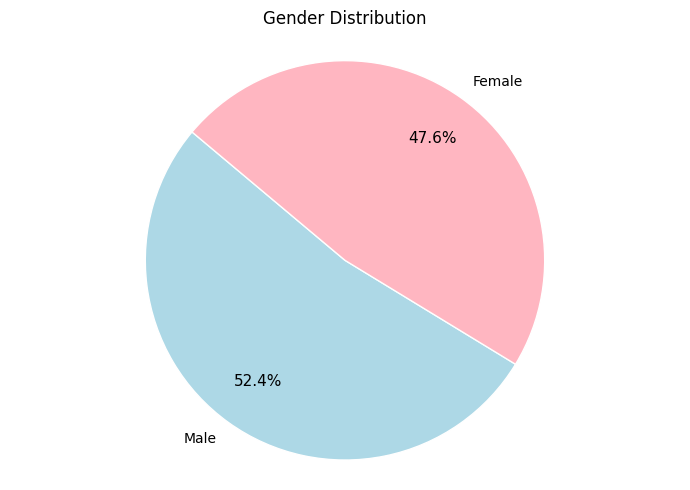

KeyError: 'AgeGroup'

<Figure size 400x400 with 0 Axes>

In [ ]:
#Gender distribution visualization
gender_counts = df["Gender"].value_counts()
shipping_status_counts = df["Shipping Status"].value_counts()
plt.figure(figsize=(7, 5))
wedges, texts, autotexts = plt.pie(gender_counts.values, labels=gender_counts.index, colors=["lightblue", "lightpink"], autopct="%1.1f%%", startangle=140, pctdistance=0.75, wedgeprops={"edgecolor": "white", "linewidth": 1})
plt.setp(autotexts, color="black", fontsize=11)
plt.title("Gender Distribution", pad=12)
plt.axis("equal")
plt.tight_layout()
plt.show()

#Age distribution
plt.figure(figsize=(6, 4))
age_counts = df["AgeGroup"].value_counts().sort_index()
plt.bar(age_counts.index, age_counts.values, color="skyblue", edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Region distribution visualization
region_counts = df["Region"].value_counts()
plt.figure(figsize=(4, 6))
plt.bar(region_counts.index, region_counts.values, color="lightgreen", edgecolor="black")
plt.title("Region Distribution")
plt.xlabel("Region")
plt.ylabel("Count")
plt.show()

#Category distribution visualization
category_counts = df["Category"].value_counts()
plt.figure(figsize=(4, 6))
plt.bar(category_counts.index, category_counts.values, color="salmon", edgecolor="black")
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Ship Status distribution visualization
plt.figure(figsize=(7, 5))
wedges, texts, autotexts = plt.pie(shipping_status_counts.values, labels=shipping_status_counts.index, colors=["lightcoral", "lightblue", "lightgreen", "plum"], autopct="%1.1f%%", startangle=140, pctdistance=0.75, wedgeprops={"edgecolor": "white", "linewidth": 1})
plt.setp(autotexts, color="black", fontsize=11)
plt.title("Ship Status Distribution", pad=12)
plt.axis("equal")
plt.tight_layout()
plt.show()


In [ ]:
print("All month in Data set:", df["Month_name"].unique())
print("All years in Data set:", df["Year"].unique())

print("\n")

#Count amount of month in each year
print("Number of unique months per year:")
months_per_year = df.groupby("Year")["Month_name"].nunique()
print(months_per_year)

All month in Data set: <StringArray>
[ 'December',     'April',    'August',   'January',   'October',      'June',
  'February', 'September',      'July',       'May',  'November',     'March']
Length: 12, dtype: str
All years in Data set: [2023 2024]


Number of unique months per year:
Year
2023    12
2024     1
Name: Month_name, dtype: int64


จากข้อมูล Data set size มีความต่างกันมาก ไม่สามารถ นําปี ผลรวม 2024 มาเทียบกับ ปี2023 ได้โดยตรง เรา จะสามารถ วิเคราะห์ เฉพาะ เดือนที่มีเเหมือน กัน และ หาค่าเฉลี่ยแทน เท่านั้น และ ต้องคํานึงถึงความเมหาะสม